# 04_01 — Avaliação do Modelo FFT por Voo

**Input:** artefatos de `06_models/` (fft_isolation_forest, fft_feature_scaler, fft_selected_features)  
**Input:** voos de `04_feature/fft/` (features espectrais + rolling sobre sinais do motor)  

Este notebook aplica o modelo treinado pelo pipeline **`fft_model_training`** individualmente
em cada voo, permitindo visualizar:
- O anomaly score ao longo do tempo
- O momento real da falha vs. o primeiro alerta do modelo
- A latência de detecção por voo
- Uma tabela-resumo comparando todos os voos

Análogo ao `04_00`, mas usando os artefatos e features gerados pelo pipeline FFT.

## Imports e caminhos

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import yaml

from aeroespacial_2.pipelines.fft_model_training.nodes import create_windows

ROOT       = Path("..")
MODELS_DIR = ROOT / "data/06_models"
FEAT_DIR   = ROOT / "data/04_feature/fft"

_params = yaml.safe_load((ROOT / "conf/base/parameters.yml").read_text())["fft_model_training"]

TARGET_COL    = "target_fault"
TIMESTAMP_COL = "timestamp"
WINDOW_SIZE   = _params["window_size"]
SKIP_SECONDS  = _params.get("skip_seconds", 0.0)

print(f"skip_seconds carregado de parameters.yml (fft_model_training): {SKIP_SECONDS} s")
print(f"window_size: {WINDOW_SIZE}")
print(f"Diretório de features: {FEAT_DIR.resolve()}")

skip_seconds carregado de parameters.yml (fft_model_training): 20.0 s
window_size: 20
Diretório de features: /home/kunumi/projetos/capacitacao-avancada/aeroespacial-2/data/04_feature/fft


## Carrega artefatos do modelo

In [2]:
model             = joblib.load(MODELS_DIR / "fft_isolation_forest.pkl")
scaler            = joblib.load(MODELS_DIR / "fft_feature_scaler.pkl")
selected_features = json.loads((MODELS_DIR / "fft_selected_features.json").read_text())

print(f"Features selecionadas ({len(selected_features)}):")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2d}. {f}")

Features selecionadas (20):
   1. alt_global
   2. imu_accel_x_mean_200
   3. imu_accel_x_mean_100
   4. imu_accel_x_mean_50
   5. imu_accel_x
   6. imu_accel_y_mean_200
   7. imu_accel_y_mean_100
   8. imu_accel_y_mean_50
   9. imu_accel_y
  10. fft_peak_power_imu_accel_x_2000
  11. fft_entropy_mag_x_500
  12. fft_entropy_imu_accel_z_1000
  13. fft_high_ratio_mag_x_500
  14. fft_entropy_imu_accel_z_2000
  15. fft_high_ratio_mag_x_1000
  16. fft_high_ratio_imu_accel_z_2000
  17. fft_entropy_imu_accel_y_1000
  18. fft_high_ratio_imu_accel_z_1000
  19. fft_entropy_mag_z_1000
  20. fft_peak_power_imu_accel_z_2000


## Função de avaliação por voo

In [3]:
def evaluate_flight(df: pd.DataFrame, flight_name: str) -> dict | None:
    """Aplica o modelo FFT em um único voo e retorna métricas."""
    missing = [f for f in selected_features if f not in df.columns]
    if missing:
        print(f"  [SKIP] {flight_name} — features ausentes: {missing}")
        return None

    if TARGET_COL not in df.columns:
        df = df.copy()
        df[TARGET_COL] = 0

    # Remove fase de transição inicial: primeiros skip_seconds de cada voo.
    # Aplicado aqui na avaliação e também no treino (via build_training_data).
    if SKIP_SECONDS > 0.0:
        df = df[df[TIMESTAMP_COL] >= SKIP_SECONDS].copy()

    if len(df) <= WINDOW_SIZE:
        print(f"  [SKIP] {flight_name} — muito curto após skip ({len(df)} linhas)")
        return None

    X, y = create_windows(df, WINDOW_SIZE, selected_features, TARGET_COL)
    timestamps = df[TIMESTAMP_COL].values[WINDOW_SIZE:]

    X_scaled  = scaler.transform(X)
    raw_preds = model.predict(X_scaled)
    y_pred    = np.where(raw_preds == -1, 1, 0)
    scores    = model.decision_function(X_scaled)

    fault_indices = np.where(y == 1)[0]
    has_fault = len(fault_indices) > 0

    result = {
        "flight":       flight_name,
        "has_fault":    has_fault,
        "n_samples":    len(y),
        "timestamps":   timestamps,
        "y_true":       y,
        "y_pred":       y_pred,
        "scores":       scores,
        "fault_time":   None,
        "detect_time":  None,
        "latency_s":    None,
        "false_alarms": int((y_pred[y == 0] == 1).sum()),
    }

    if has_fault:
        real_idx   = fault_indices[0]
        fault_time = timestamps[real_idx]
        post_fault = np.where((y_pred == 1) & (np.arange(len(y_pred)) >= real_idx))[0]
        result["fault_time"] = float(fault_time)
        if len(post_fault) > 0:
            detect_time = timestamps[post_fault[0]]
            result["detect_time"] = float(detect_time)
            result["latency_s"]   = float(detect_time - fault_time)

    return result

## Avalia todos os voos

In [4]:
all_results = []
csv_files   = sorted(FEAT_DIR.glob("*.csv"))

print(f"Voos encontrados: {len(csv_files)}\n")
for path in csv_files:
    df   = pd.read_csv(path)
    name = path.stem
    res  = evaluate_flight(df, name)
    if res is not None:
        all_results.append(res)
        tag = "✓ DETECTADO" if res["detect_time"] else ("✗ NÃO DETECTADO" if res["has_fault"] else "— sem falha")
        lat = f"latência={res['latency_s']:.2f}s" if res["latency_s"] is not None else ""
        print(f"  {name[:60]:<60} {tag}  {lat}")

print(f"\nTotal avaliado: {len(all_results)} voos")

Voos encontrados: 33

  carbonZ_2018-07-18-15-53-31_1_engine_failure                 ✗ NÃO DETECTADO  
  carbonZ_2018-07-18-15-53-31_2_engine_failure                 ✗ NÃO DETECTADO  
  carbonZ_2018-07-18-16-22-01_engine_failure_with_emr_traj     ✓ DETECTADO  latência=2.17s
  carbonZ_2018-07-18-16-37-39_1_no_failure                     — sem falha  
  carbonZ_2018-07-18-16-37-39_2_engine_failure_with_emr_traj   ✓ DETECTADO  latência=2.85s
  carbonZ_2018-07-30-16-29-45_engine_failure_with_emr_traj     ✓ DETECTADO  latência=5.07s
  carbonZ_2018-07-30-16-39-00_1_engine_failure                 ✓ DETECTADO  latência=14.64s
  carbonZ_2018-07-30-16-39-00_2_engine_failure                 ✗ NÃO DETECTADO  
  carbonZ_2018-07-30-16-39-00_3_no_failure                     — sem falha  
  carbonZ_2018-07-30-17-10-45_engine_failure_with_emr_traj     ✗ NÃO DETECTADO  
  carbonZ_2018-07-30-17-20-01_engine_failure_with_emr_traj     ✓ DETECTADO  latência=2.80s
  carbonZ_2018-07-30-17-36-35_engine_failure

## Tabela-resumo

In [5]:
rows = []
for r in all_results:
    rows.append({
        "Voo":           r["flight"].replace("carbonZ_", ""),
        "Falha real":    "Sim" if r["has_fault"] else "Não",
        "Detectado":     "Sim" if r["detect_time"] else ("Não" if r["has_fault"] else "—"),
        "t_falha (s)":   f"{r['fault_time']:.1f}" if r["fault_time"] else "—",
        "t_alerta (s)":  f"{r['detect_time']:.1f}" if r["detect_time"] else "—",
        "Latência (s)":  f"{r['latency_s']:.2f}" if r["latency_s"] is not None else "—",
        "Falsos alarmes": r["false_alarms"],
    })

summary = pd.DataFrame(rows)

detected = summary[summary["Detectado"] == "Sim"]
missed   = summary[(summary["Falha real"] == "Sim") & (summary["Detectado"] == "Não")]
no_fault = summary[summary["Falha real"] == "Não"]

print(f"Falhas detectadas:     {len(detected)}")
print(f"Falhas não detectadas: {len(missed)}")
print(f"Voos normais:          {len(no_fault)}")
if len(detected) > 0:
    lats = [r["latency_s"] for r in all_results if r["latency_s"] is not None]
    print(f"Latência média:        {np.mean(lats):.2f}s")
    print(f"Latência mediana:      {np.median(lats):.2f}s")

summary

Falhas detectadas:     15
Falhas não detectadas: 8
Voos normais:          10
Latência média:        4.57s
Latência mediana:      2.64s


,Voo,Falha real,Detectado,t_falha (s),t_alerta (s),Latência (s),Falsos alarmes
0,2018-07-18-15-53-31_1_engine_failure,Sim,Não,115.3,—,—,69
1,2018-07-18-15-53-31_2_engine_failure,Sim,Não,72.4,—,—,264
2,2018-07-18-16-22-01_engine_failure_with_emr_traj,Sim,Sim,115.6,117.8,2.17,755
3,2018-07-18-16-37-39_1_no_failure,Não,—,—,—,—,0
4,2018-07-18-16-37-39_2_engine_failure_with_emr_...,Sim,Sim,113.1,115.9,2.85,0
5,2018-07-30-16-29-45_engine_failure_with_emr_traj,Sim,Sim,122.2,127.2,5.07,380
6,2018-07-30-16-39-00_1_engine_failure,Sim,Sim,115.8,130.4,14.64,543
7,2018-07-30-16-39-00_2_engine_failure,Sim,Não,90.7,—,—,220
8,2018-07-30-16-39-00_3_no_failure,Não,—,—,—,—,184
9,2018-07-30-17-10-45_engine_failure_with_emr_traj,Sim,Não,116.2,—,—,0


## Visualização por voo

Cada gráfico mostra:
- **Painel superior:** falha real (vermelho) vs. alertas do modelo (azul)
- **Painel inferior:** anomaly score — quanto mais negativo, mais anômalo

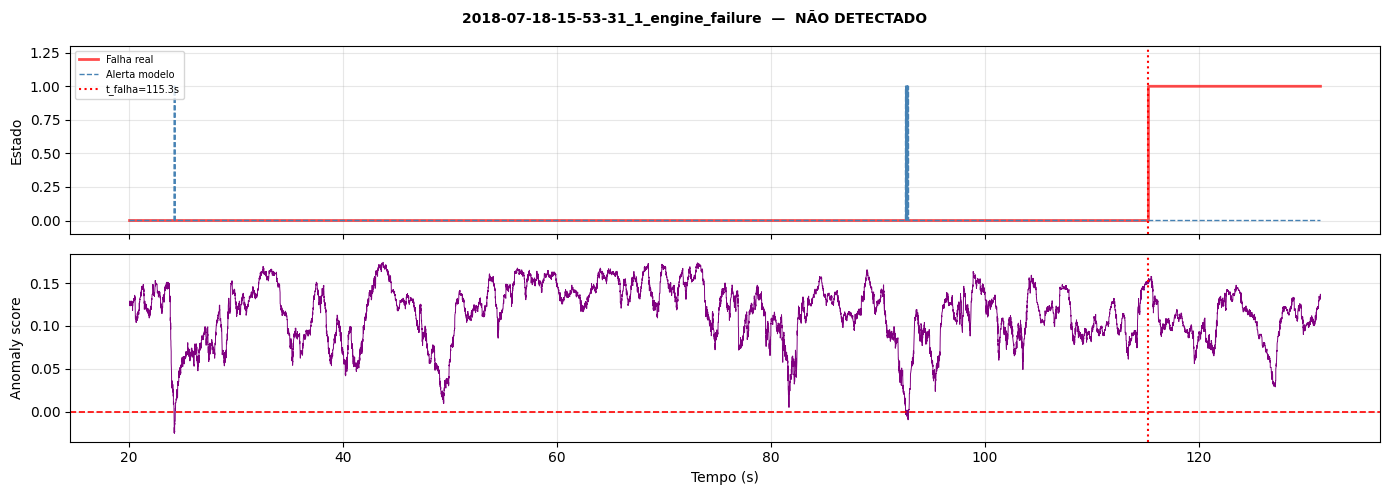

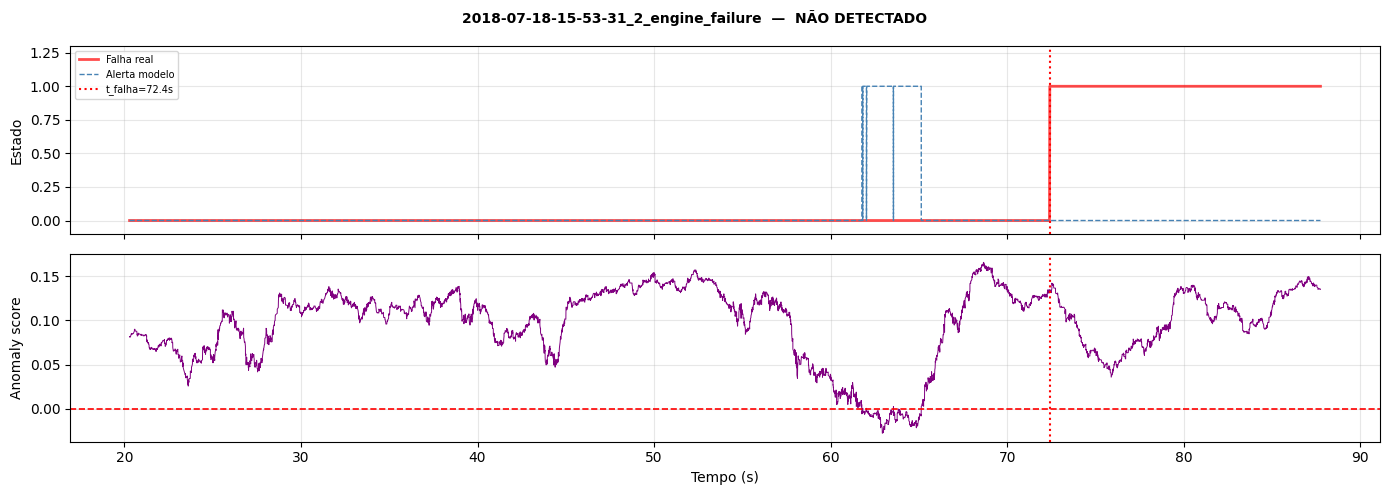

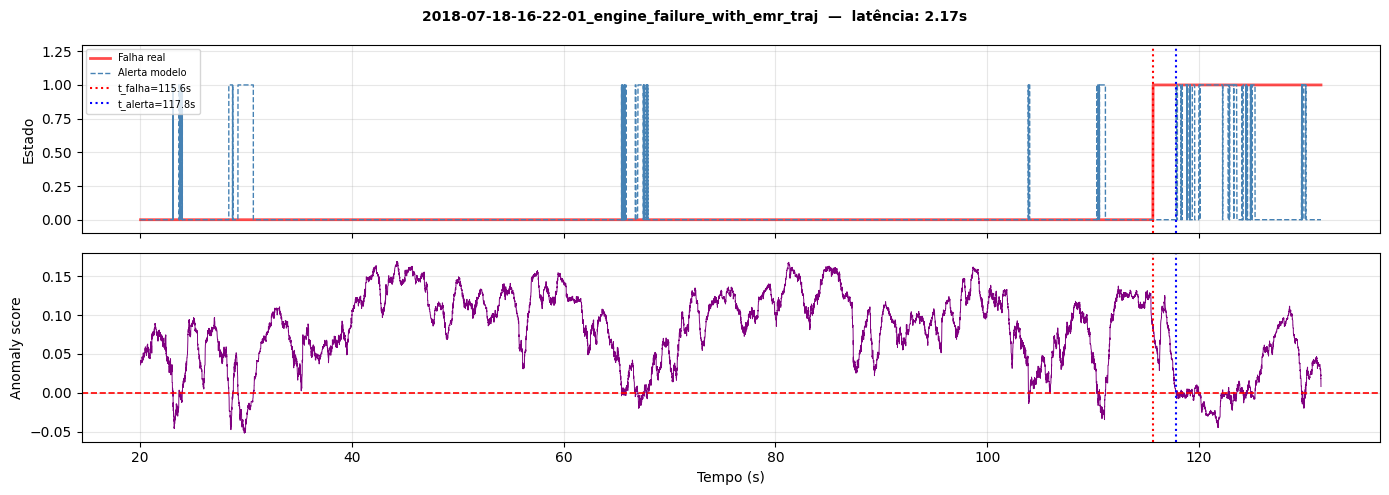

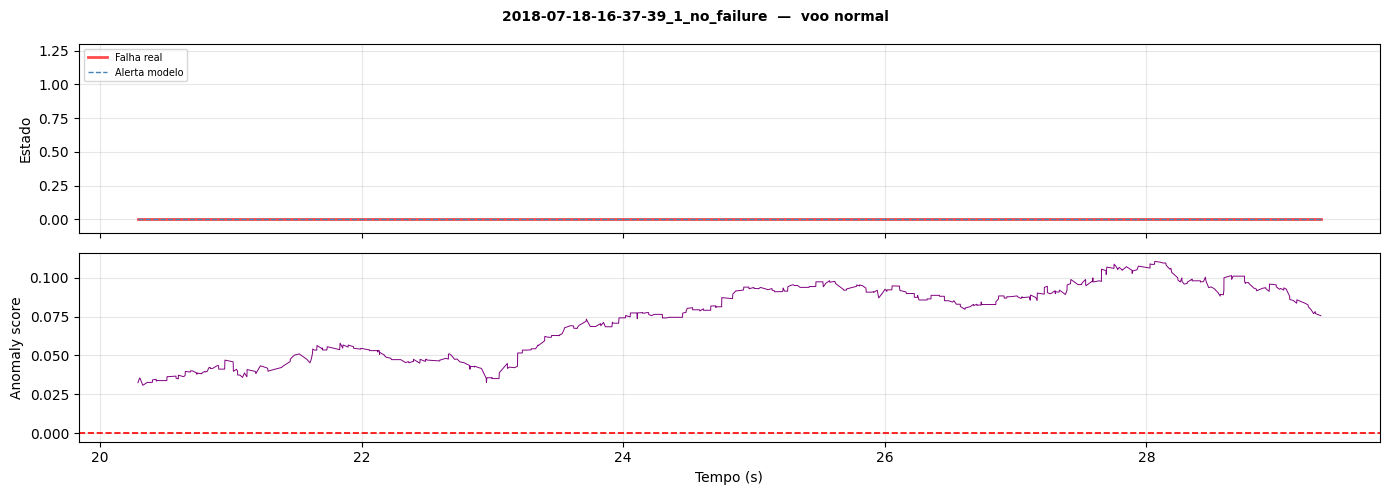

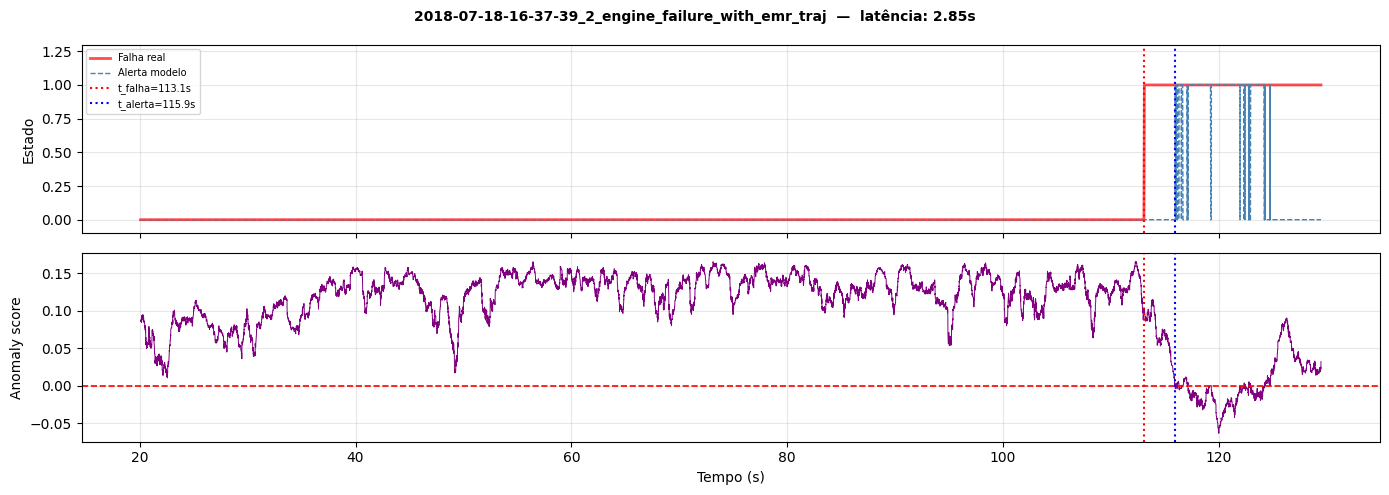

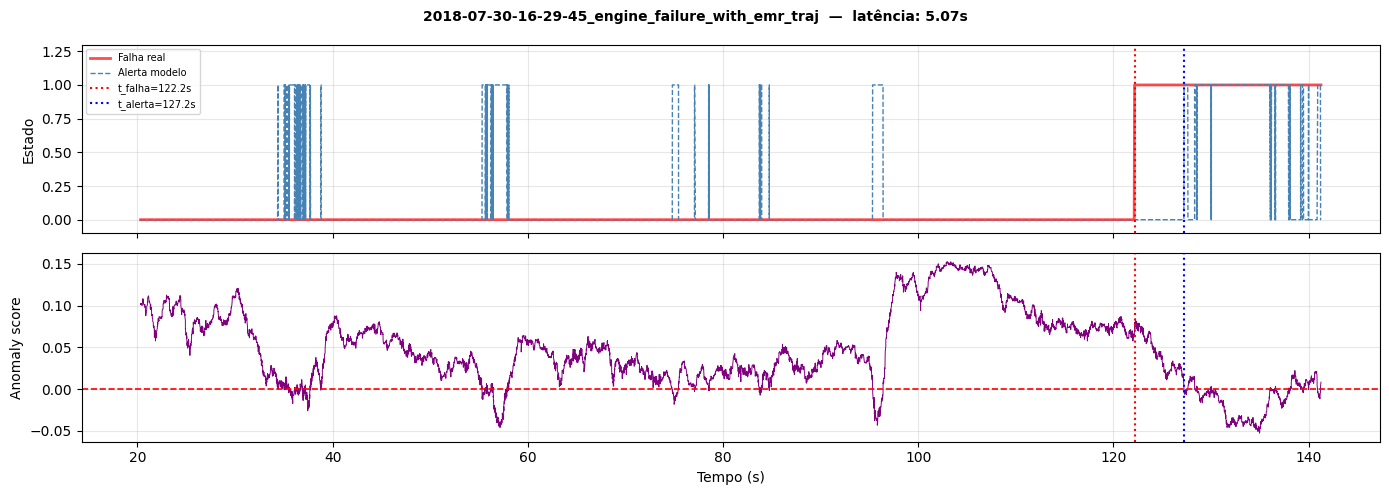

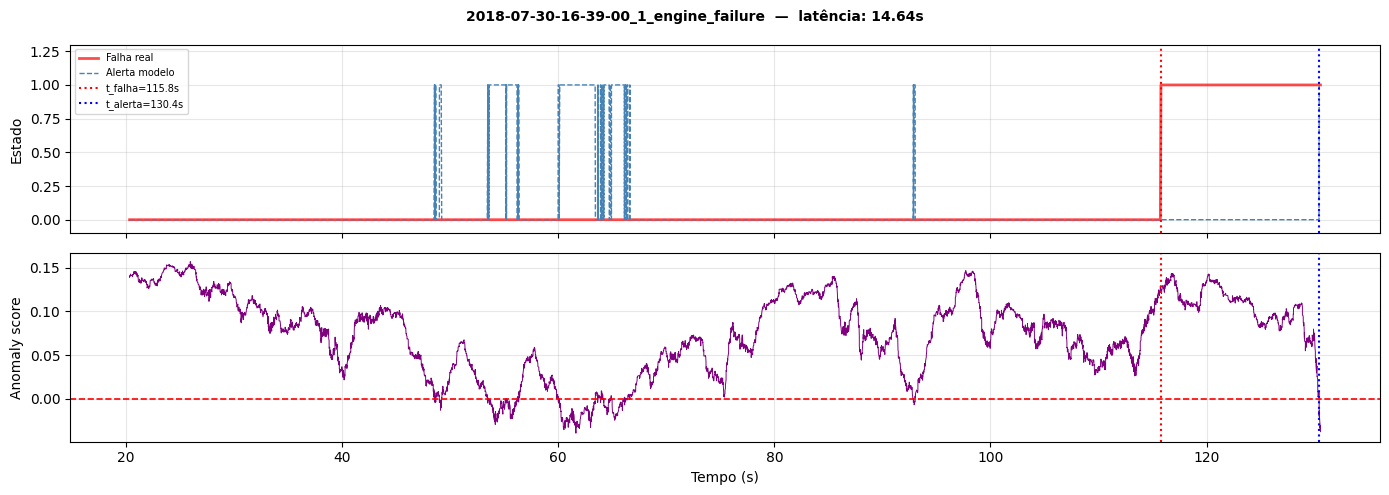

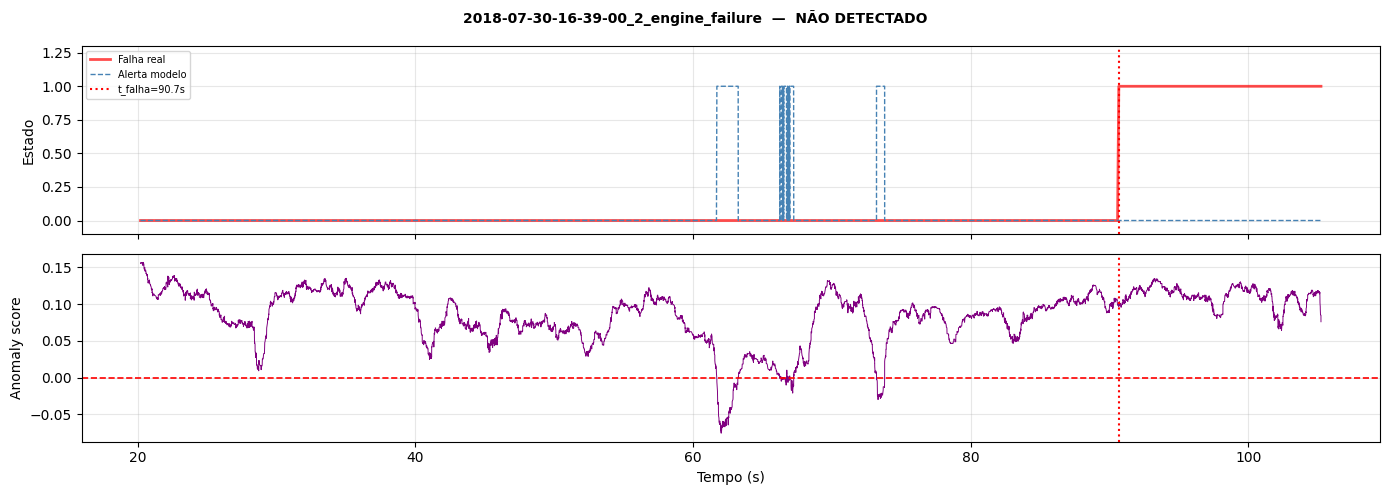

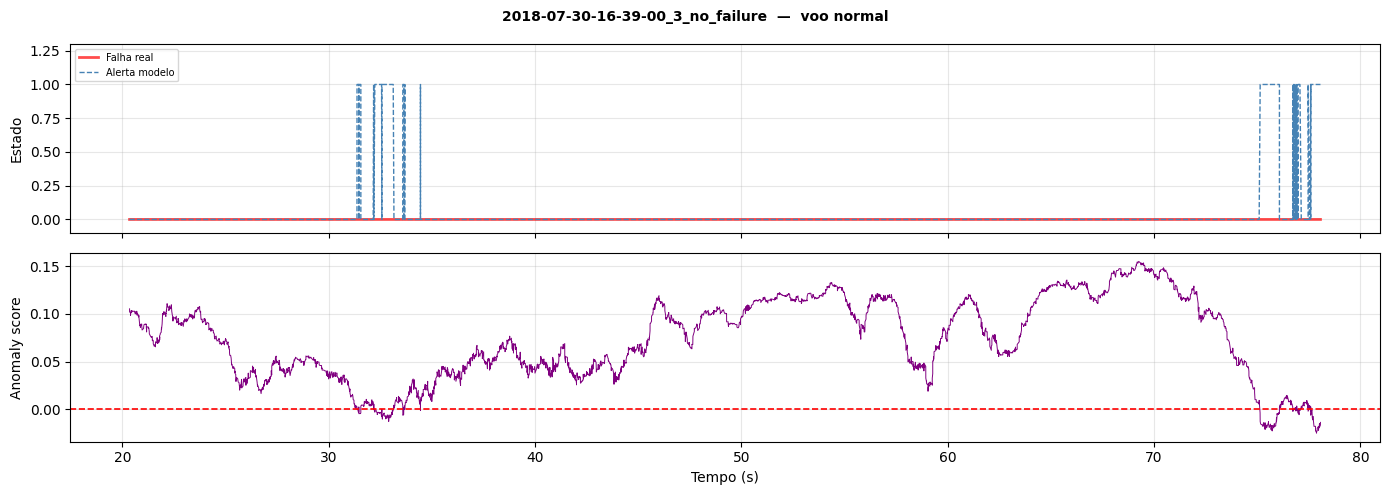

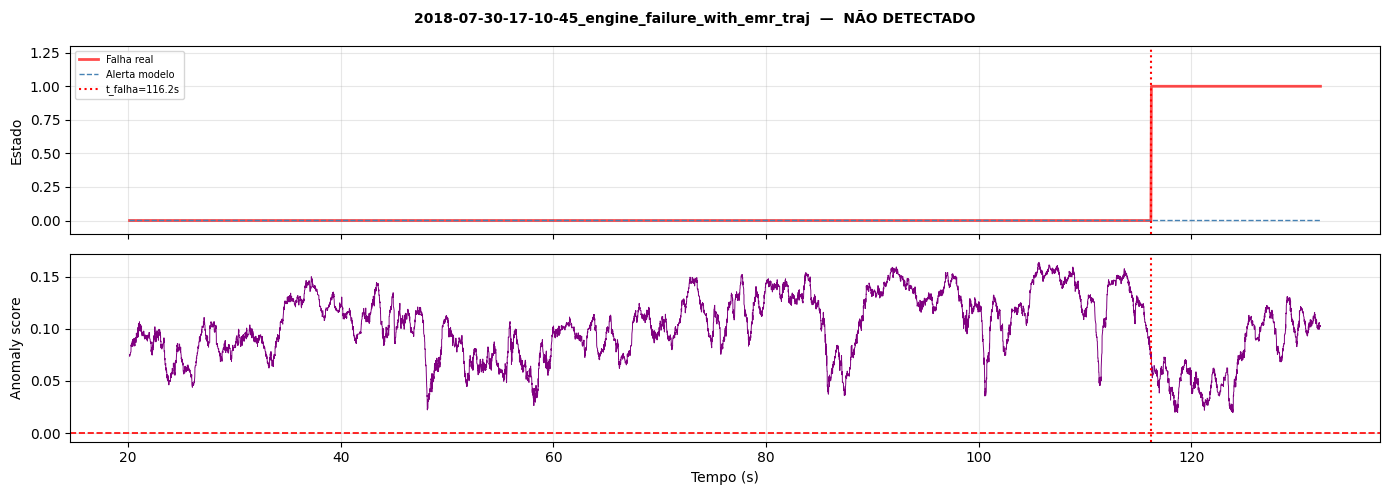

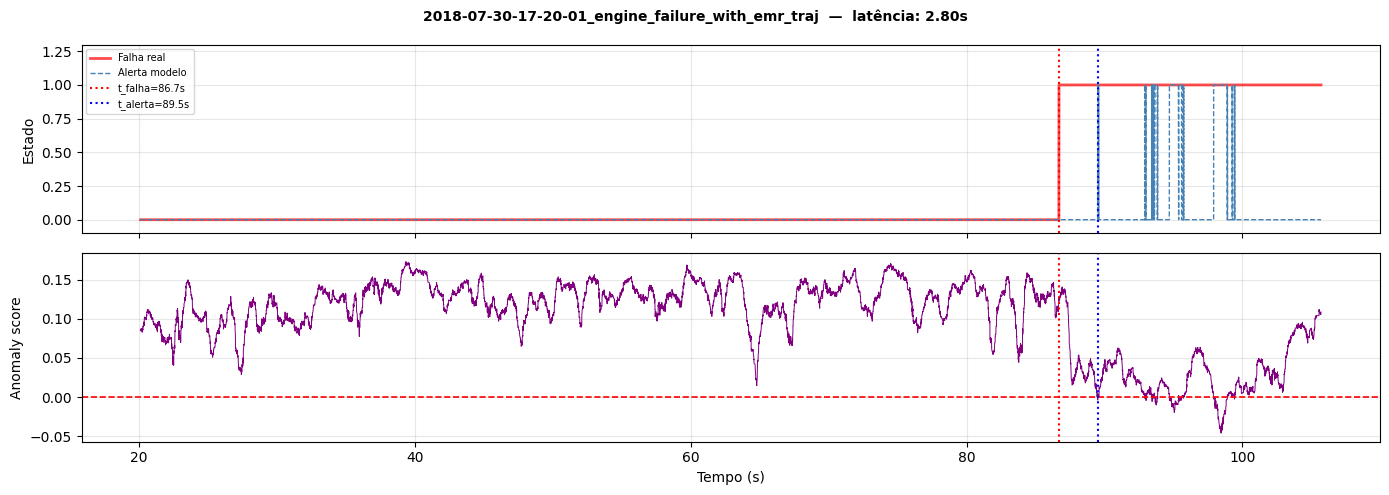

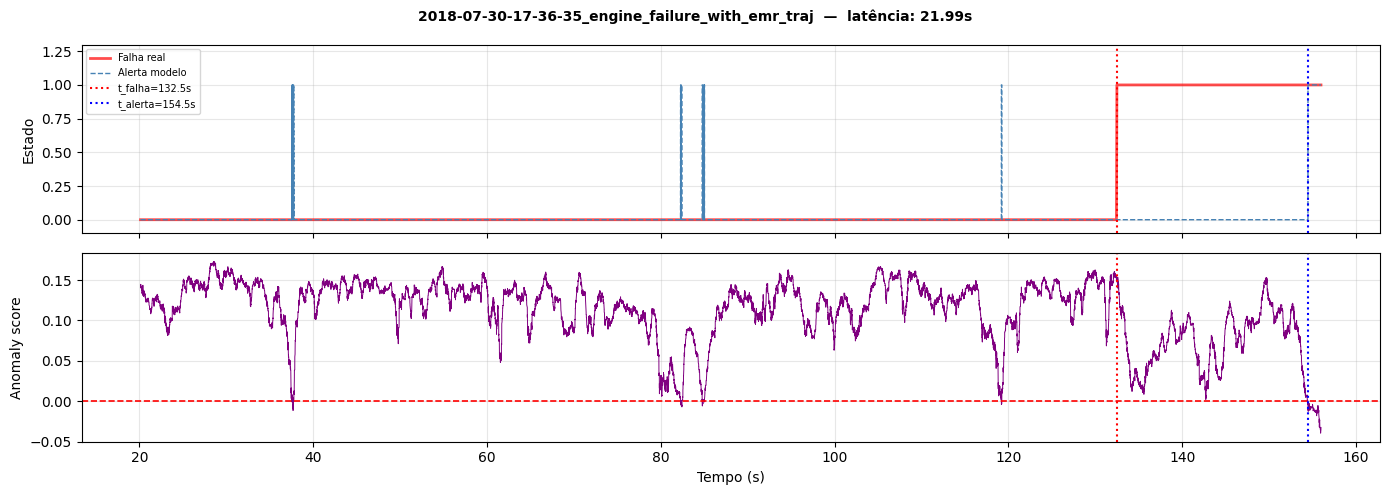

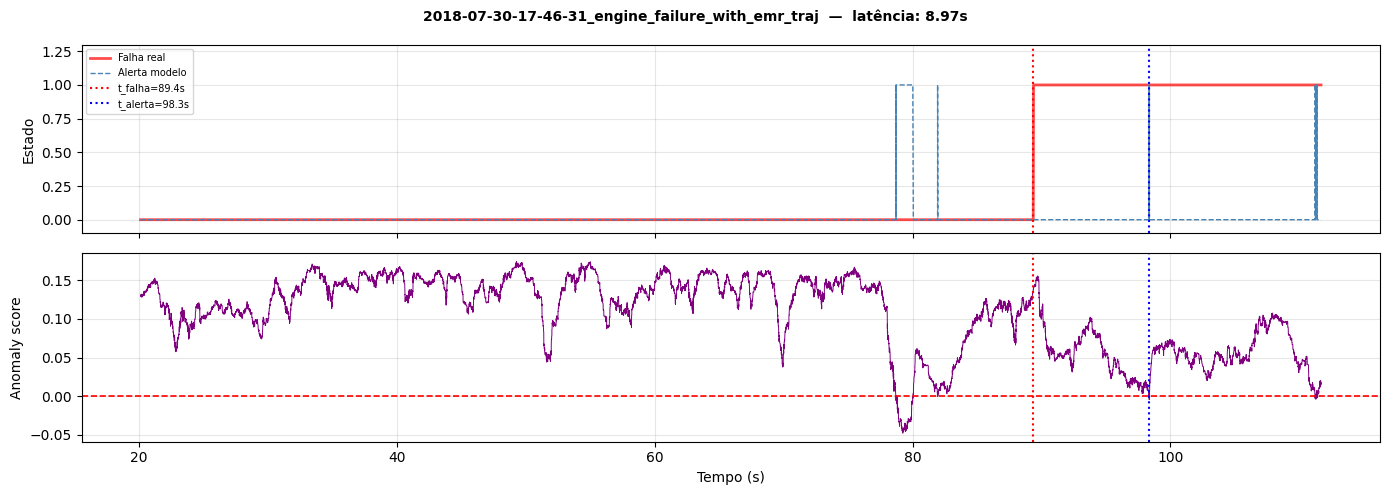

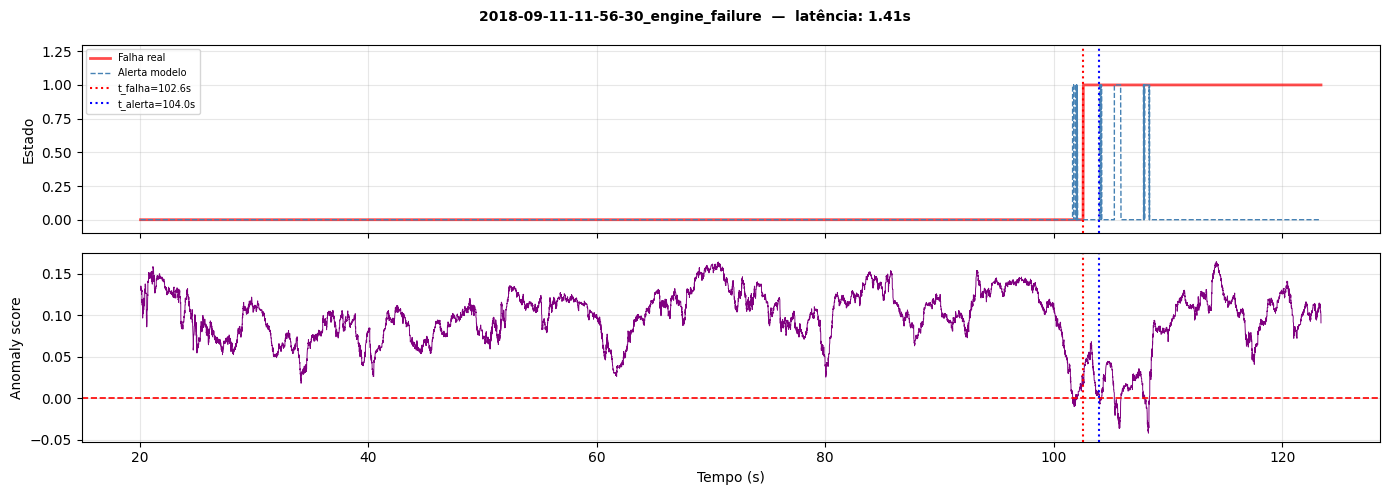

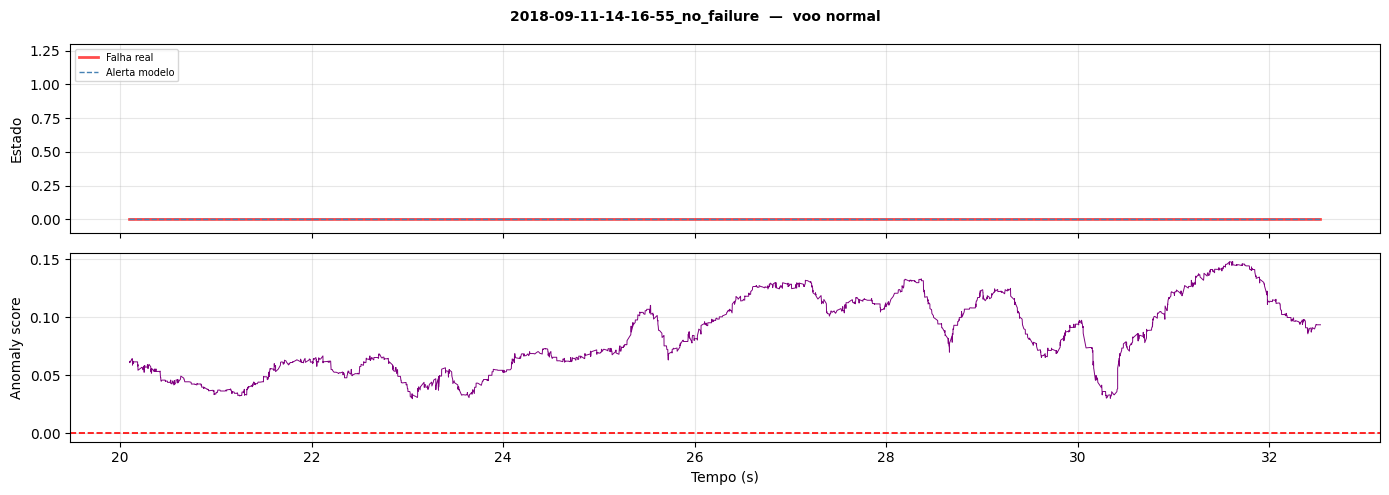

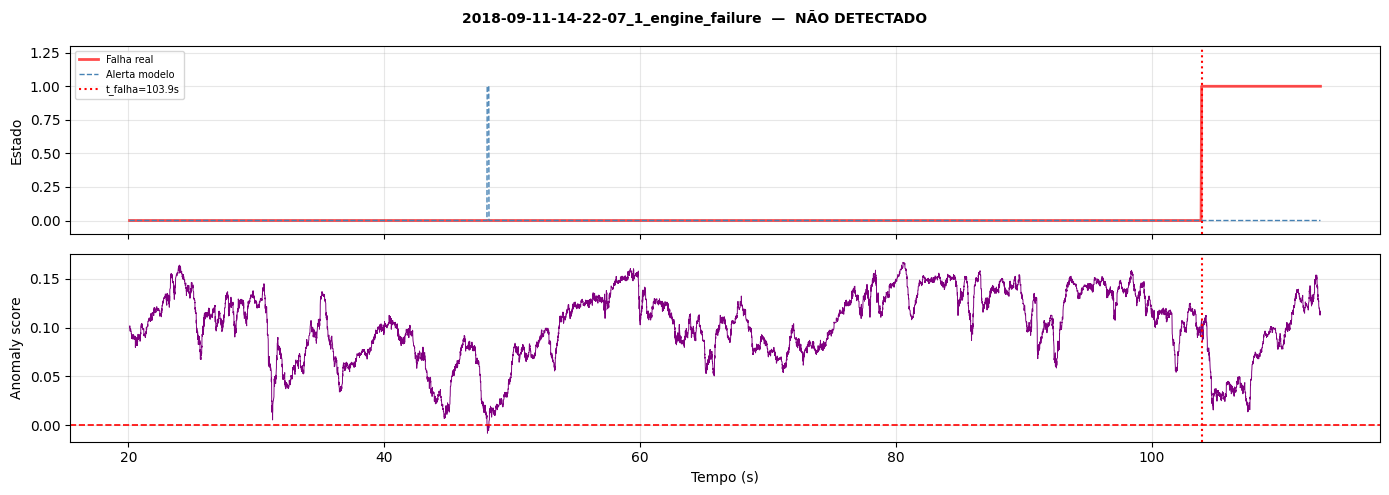

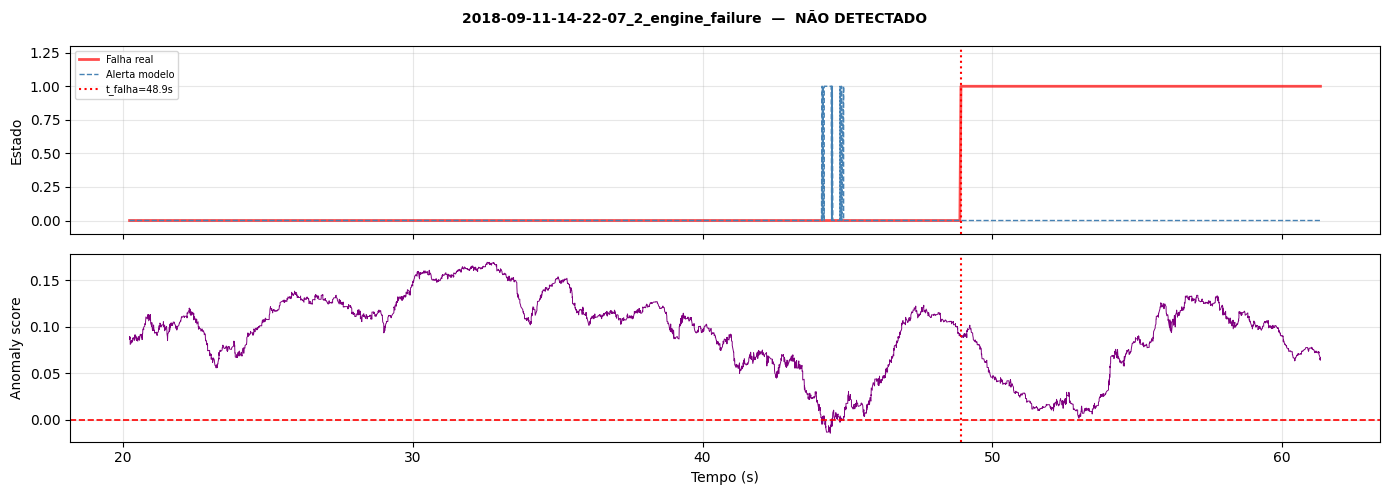

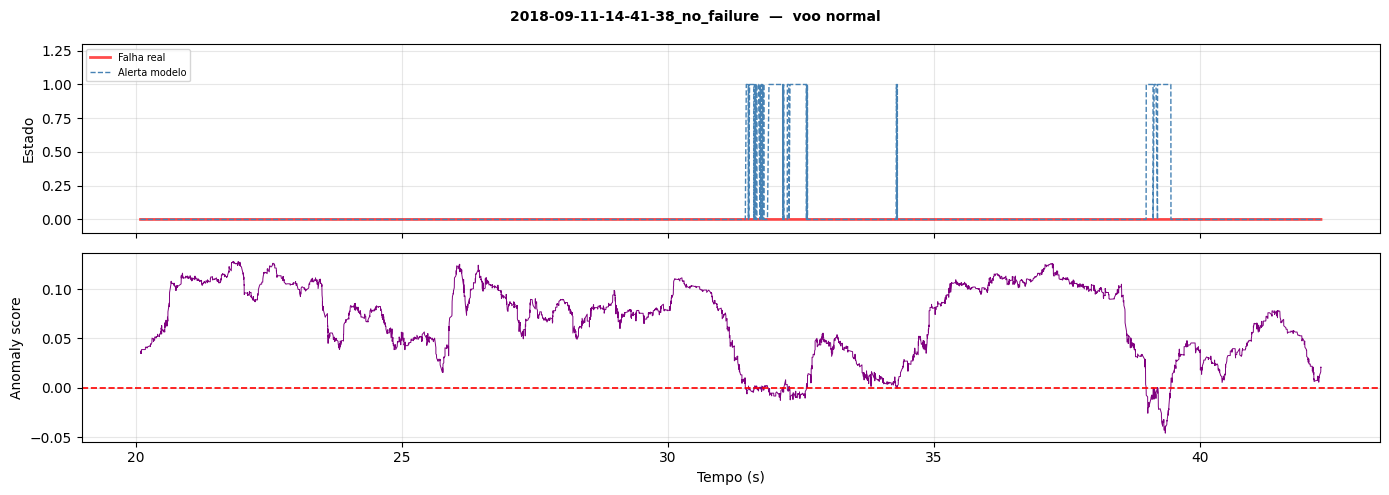

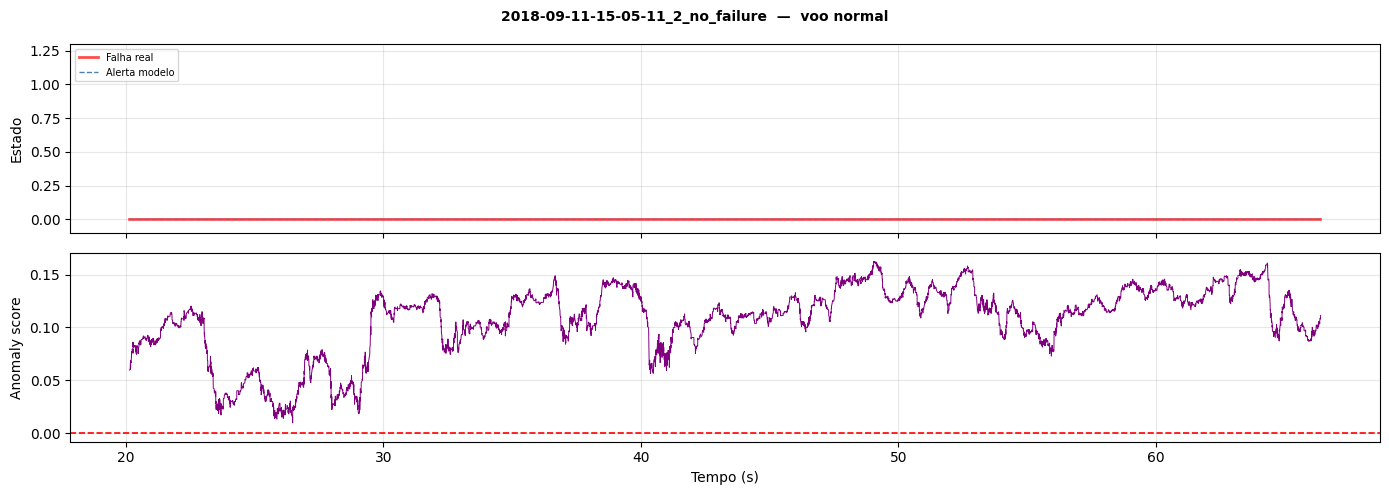

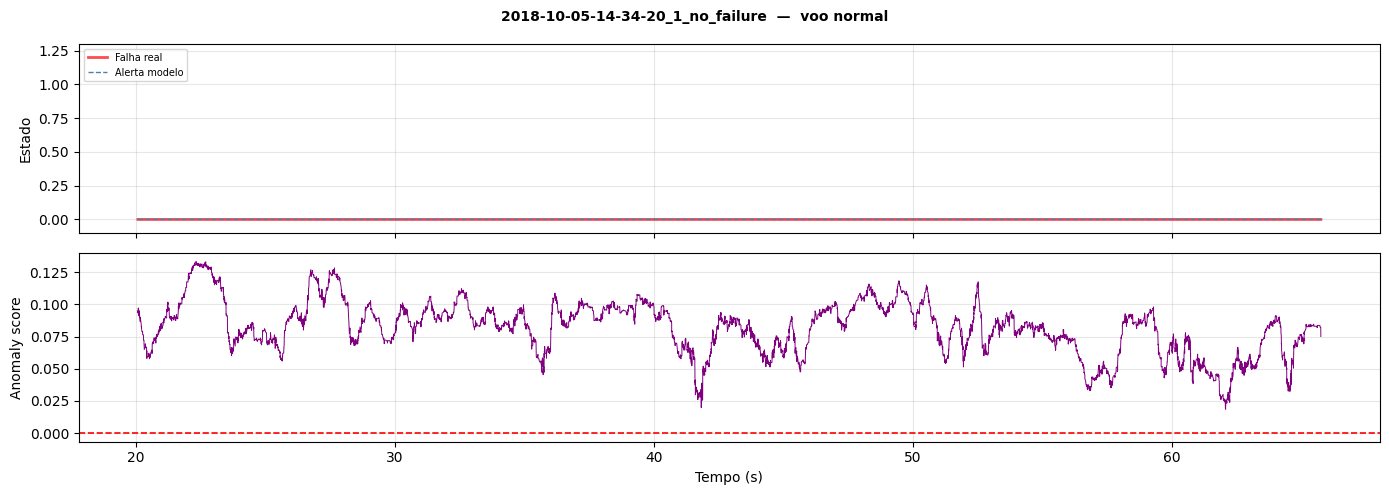

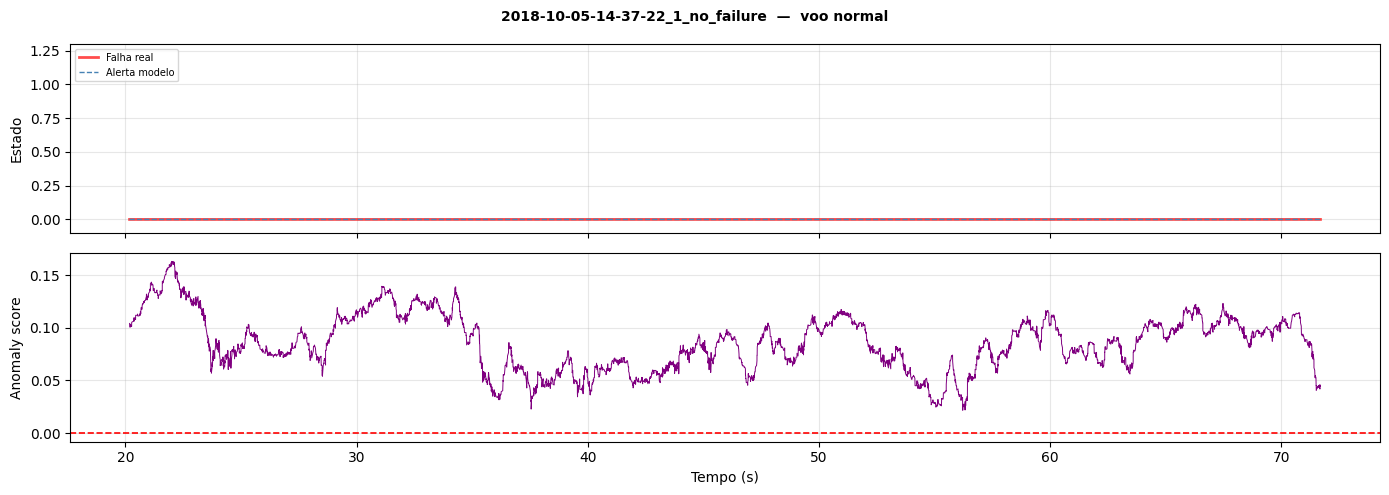

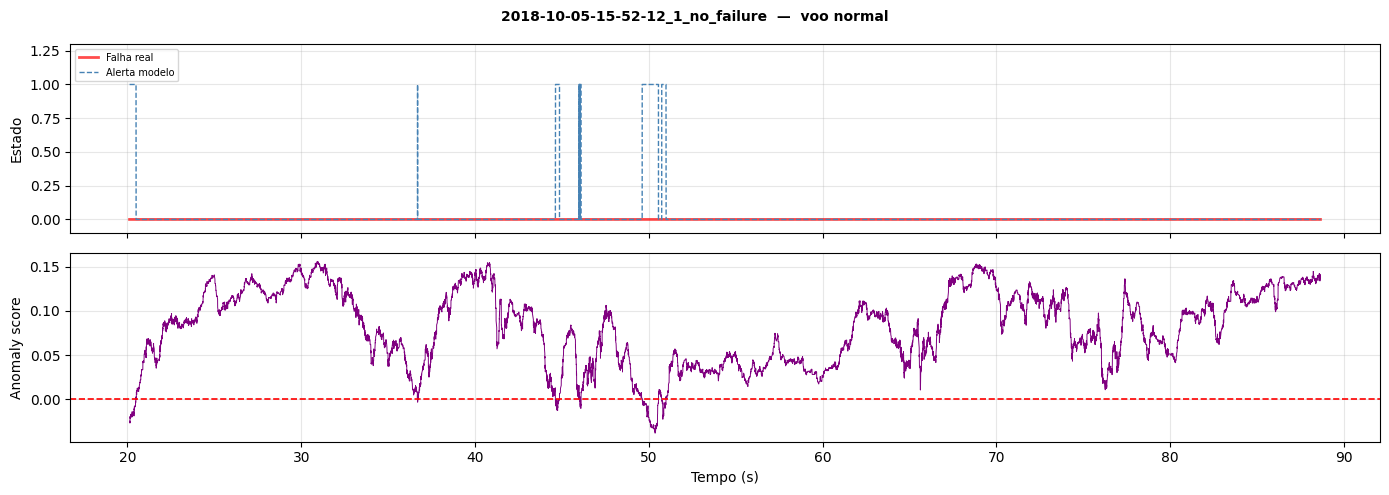

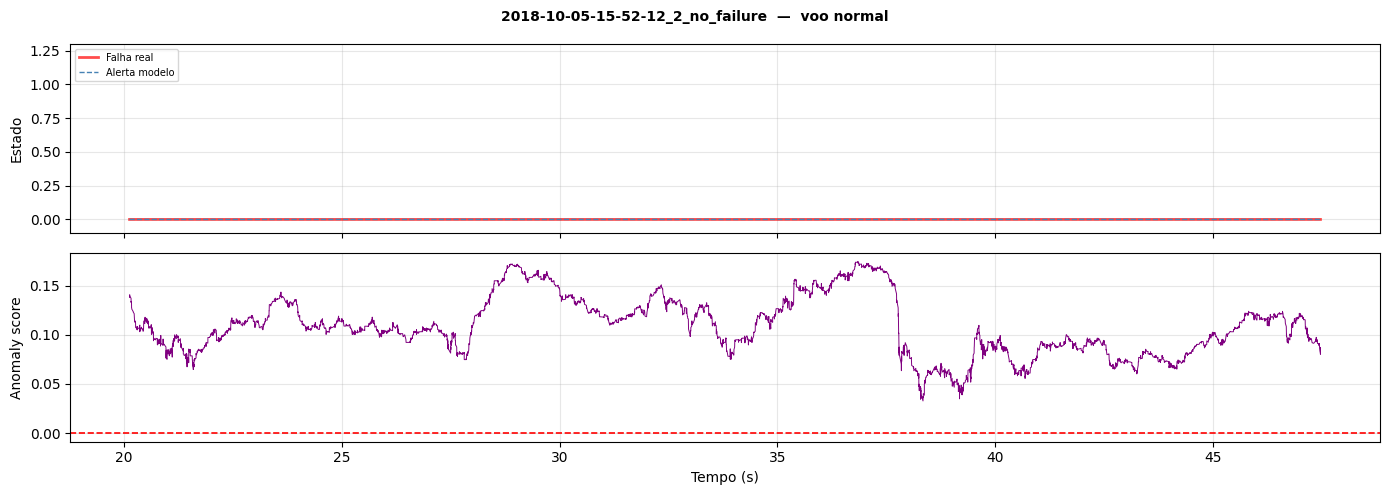

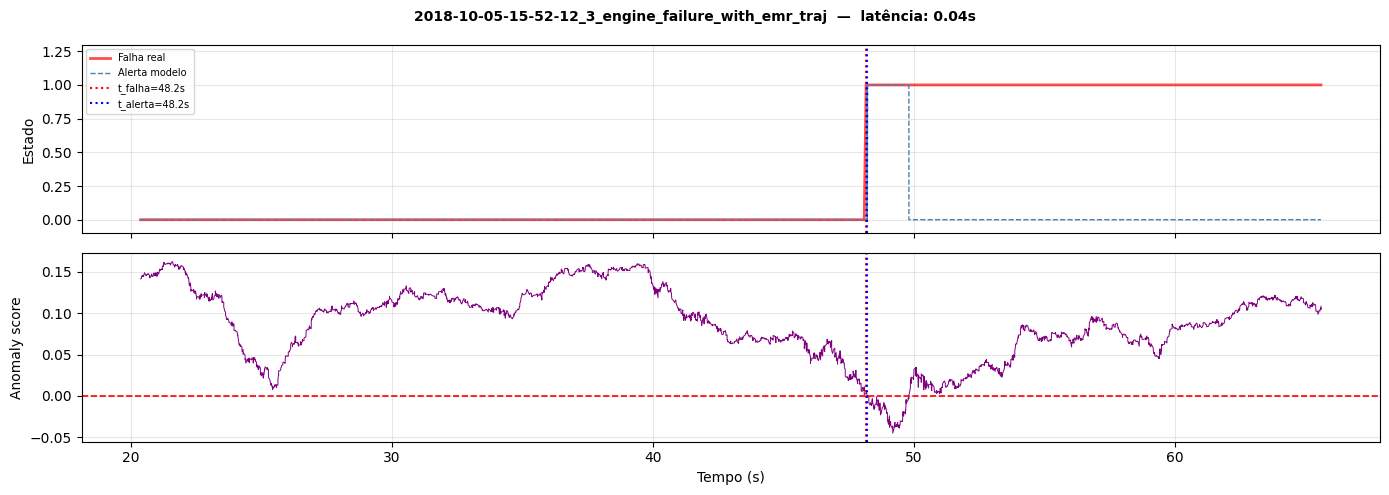

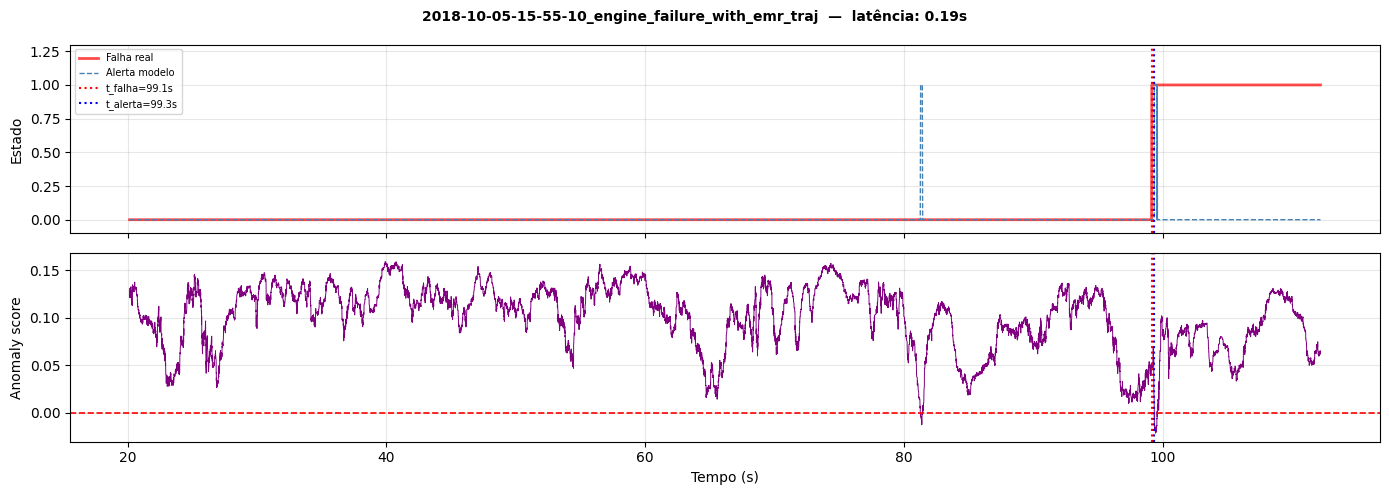

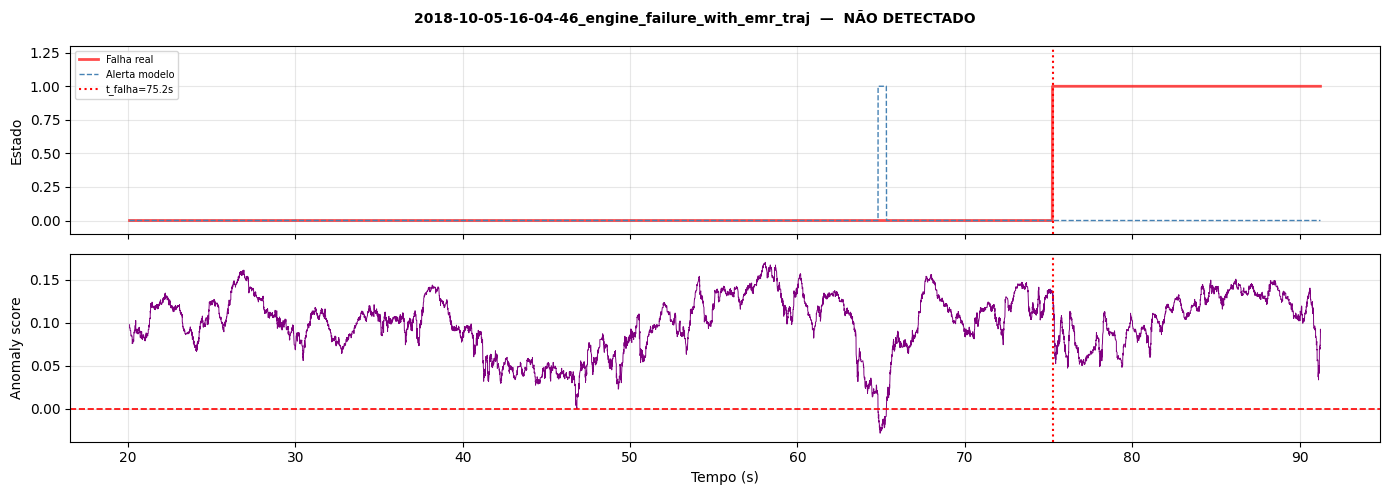

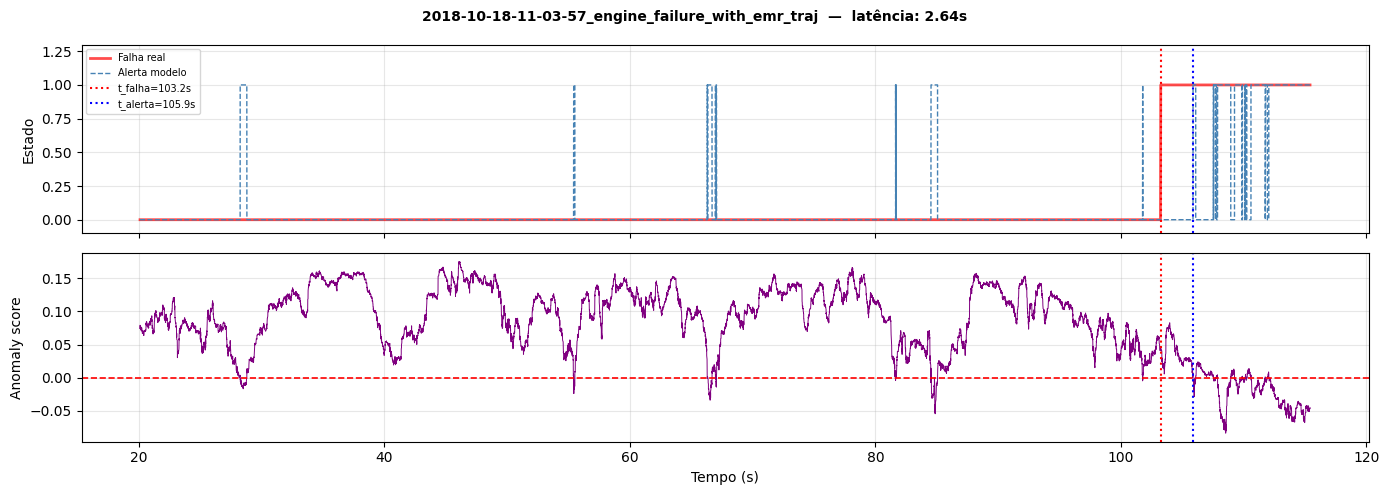

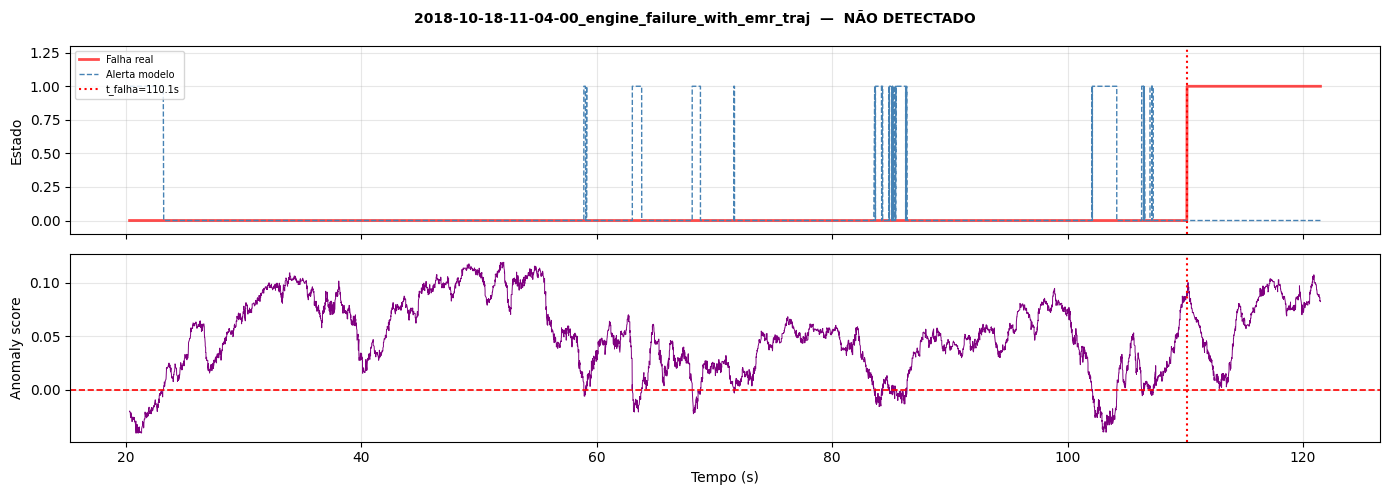

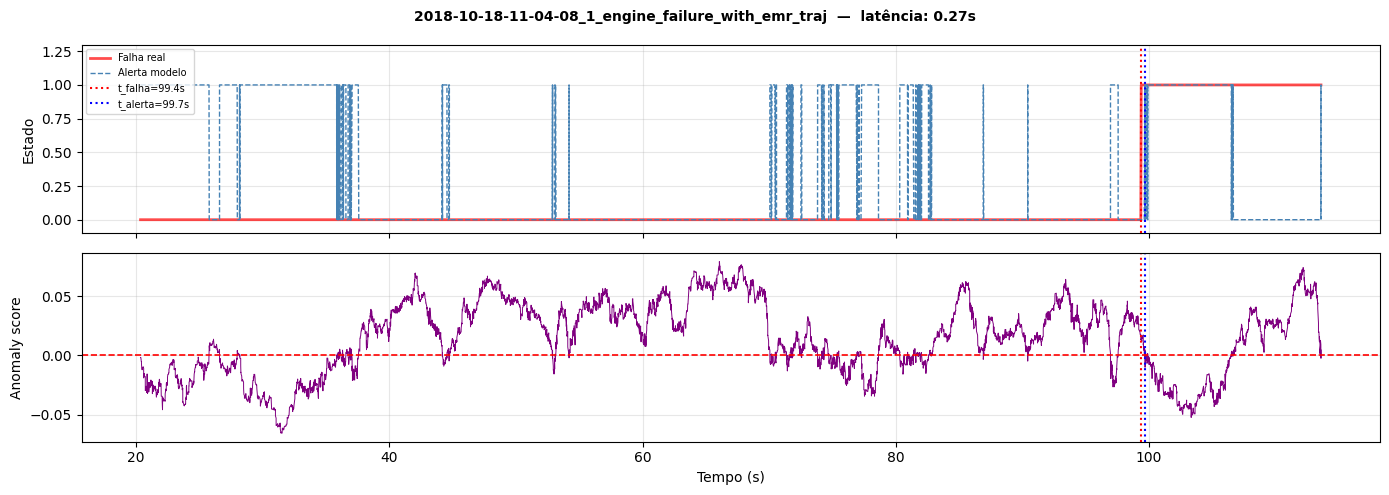

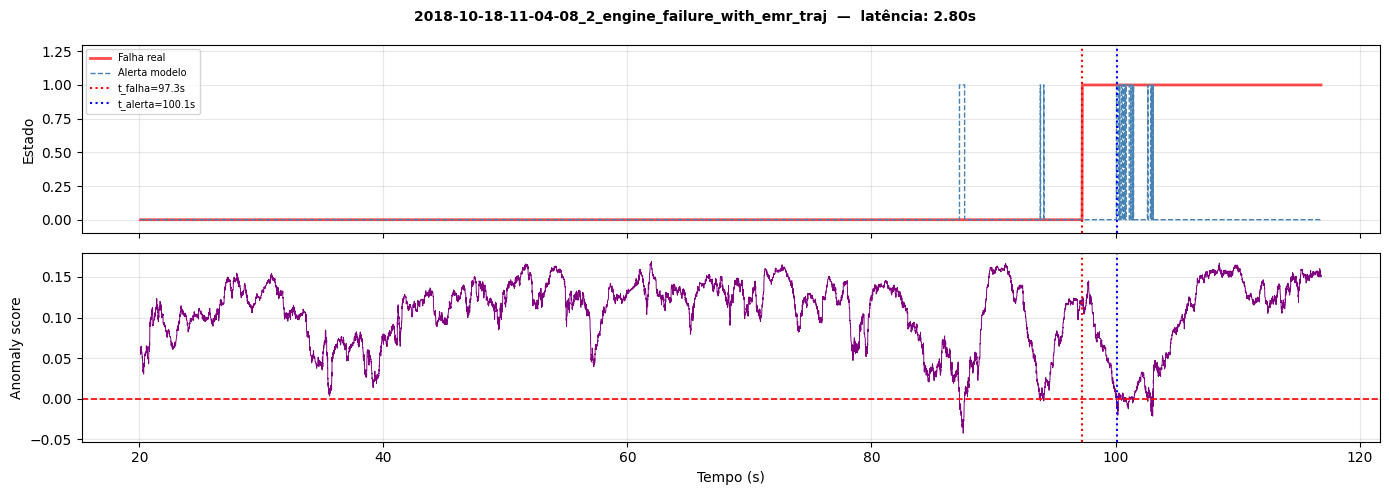

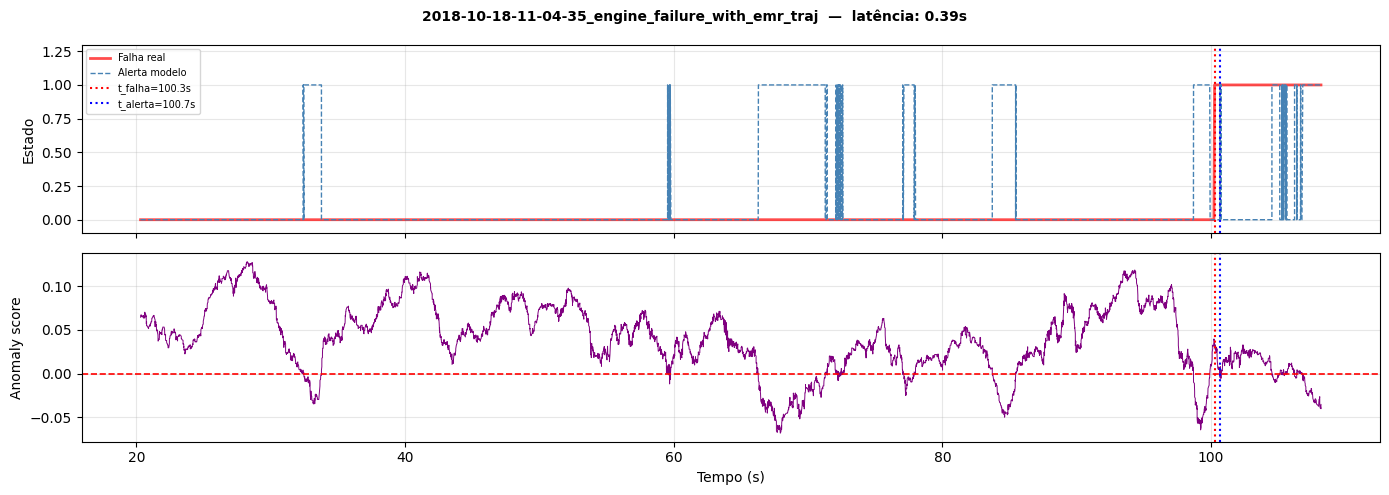

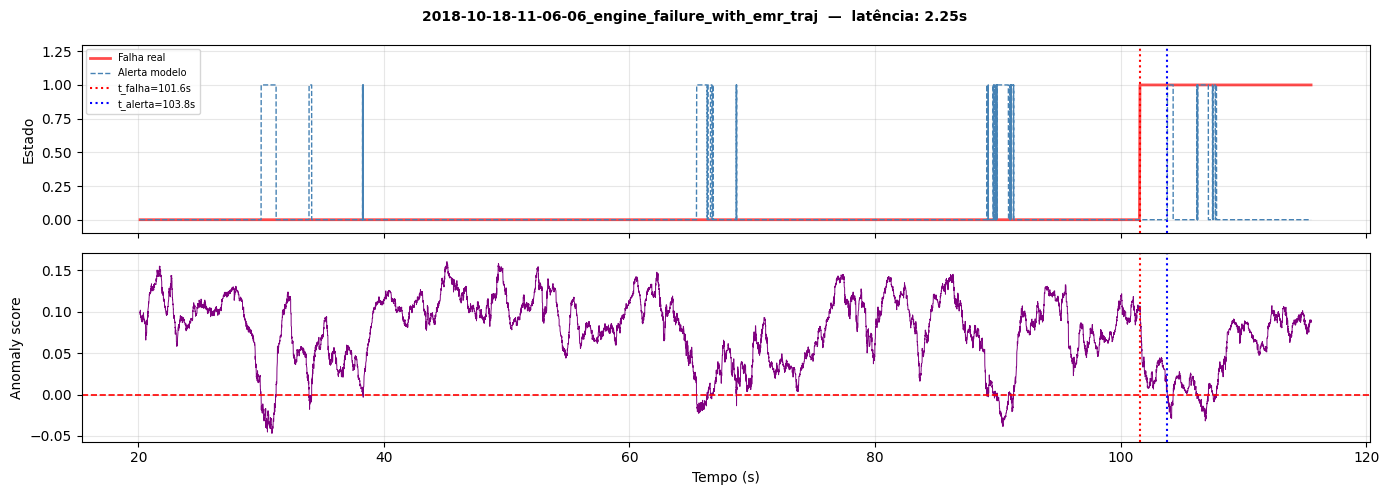

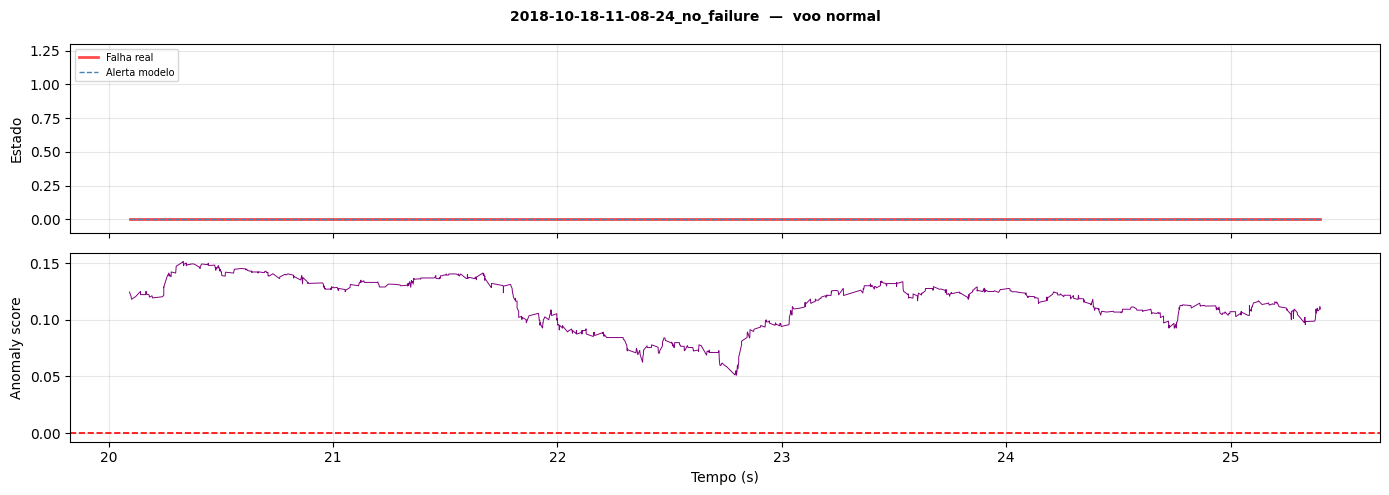

In [6]:
def plot_flight(r: dict, ax_top, ax_bot):
    ts, y_true, y_pred, scores = r["timestamps"], r["y_true"], r["y_pred"], r["scores"]

    ax_top.plot(ts, y_true, color="red",       alpha=0.7, lw=2,   label="Falha real")
    ax_top.plot(ts, y_pred, color="steelblue", lw=1, ls="--",     label="Alerta modelo")
    if r["fault_time"]:
        ax_top.axvline(r["fault_time"],  color="red",  lw=1.5, ls=":", label=f"t_falha={r['fault_time']:.1f}s")
    if r["detect_time"]:
        ax_top.axvline(r["detect_time"], color="blue", lw=1.5, ls=":", label=f"t_alerta={r['detect_time']:.1f}s")
    ax_top.set_ylabel("Estado")
    ax_top.set_ylim(-0.1, 1.3)
    ax_top.legend(fontsize=7, loc="upper left")
    ax_top.grid(True, alpha=0.3)

    ax_bot.plot(ts, scores, color="purple", lw=0.7)
    ax_bot.axhline(0, color="red", lw=1.2, ls="--", label="Limiar")
    if r["fault_time"]:
        ax_bot.axvline(r["fault_time"],  color="red",  lw=1.5, ls=":")
    if r["detect_time"]:
        ax_bot.axvline(r["detect_time"], color="blue", lw=1.5, ls=":")
    ax_bot.set_ylabel("Anomaly score")
    ax_bot.set_xlabel("Tempo (s)")
    ax_bot.grid(True, alpha=0.3)


for r in all_results:
    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
    label = r["flight"].replace("carbonZ_", "")
    if r["latency_s"] is not None:
        titulo = f"{label}  —  latência: {r['latency_s']:.2f}s"
    elif r["has_fault"] and r["detect_time"] is None:
        titulo = f"{label}  —  NÃO DETECTADO"
    else:
        titulo = f"{label}  —  voo normal"
    fig.suptitle(titulo, fontsize=10, fontweight="bold")
    plot_flight(r, ax_top, ax_bot)
    plt.tight_layout()
    plt.show()

## Distribuição de latências (voos com falha detectada)

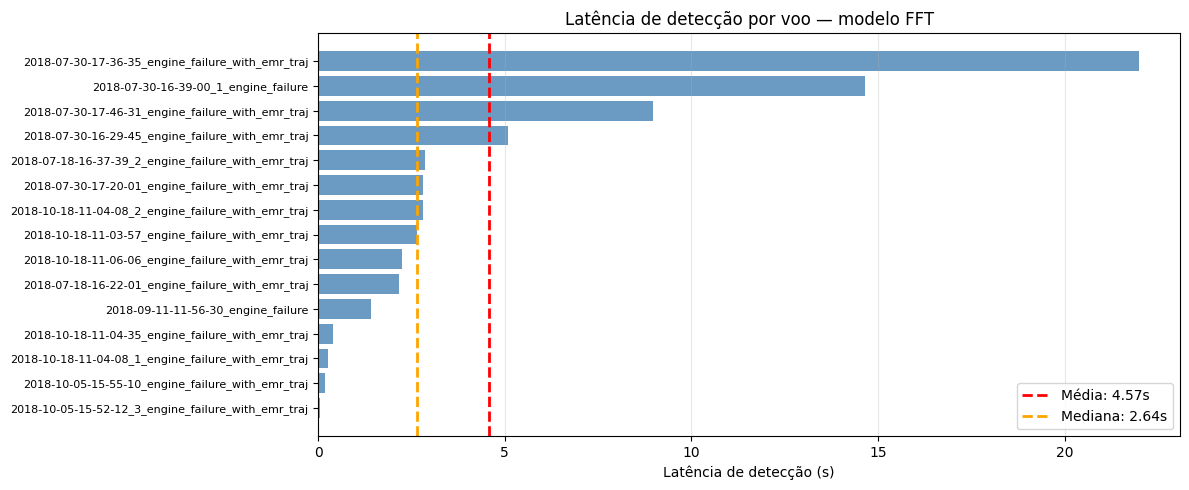

In [7]:
latencias = [(r["flight"].replace("carbonZ_", ""), r["latency_s"])
             for r in all_results if r["latency_s"] is not None]

if latencias:
    nomes, vals = zip(*sorted(latencias, key=lambda x: x[1]))
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(range(len(vals)), vals, color="steelblue", alpha=0.8)
    ax.axvline(np.mean(vals),   color="red",    lw=2, ls="--", label=f"Média: {np.mean(vals):.2f}s")
    ax.axvline(np.median(vals), color="orange", lw=2, ls="--", label=f"Mediana: {np.median(vals):.2f}s")
    ax.set_yticks(range(len(nomes)))
    ax.set_yticklabels([n[:55] for n in nomes], fontsize=8)
    ax.set_xlabel("Latência de detecção (s)")
    ax.set_title("Latência de detecção por voo — modelo FFT")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma falha detectada — verifique o parâmetro contamination.")

## Matriz de Confusão — Voos com falha real

Considera apenas os voos que **tiveram falha real** e classifica cada um em uma de três categorias,
com base no **primeiro alerta** emitido pelo modelo:

| Categoria | Descrição |
|-----------|----------|
| **Durante a falha (TP)** | Primeiro alerta ocorre dentro do período em que `y_true == 1` |
| **Antes da falha (FP antecipado)** | Primeiro alerta ocorre **antes** do início da falha real |
| **Sem alerta (FN)** | Modelo não emitiu nenhum alerta durante o voo |

Voo                                                           Classificação
--------------------------------------------------------------------------------
  2018-07-18-15-53-31_1_engine_failure                        Antes da falha (FP)
  2018-07-18-15-53-31_2_engine_failure                        Antes da falha (FP)
  2018-07-18-16-22-01_engine_failure_with_emr_traj            Antes da falha (FP)
  2018-07-18-16-37-39_2_engine_failure_with_emr_traj          Durante a falha (TP)
  2018-07-30-16-29-45_engine_failure_with_emr_traj            Antes da falha (FP)
  2018-07-30-16-39-00_1_engine_failure                        Antes da falha (FP)
  2018-07-30-16-39-00_2_engine_failure                        Antes da falha (FP)
  2018-07-30-17-10-45_engine_failure_with_emr_traj            Sem alerta (FN)
  2018-07-30-17-20-01_engine_failure_with_emr_traj            Durante a falha (TP)
  2018-07-30-17-36-35_engine_failure_with_emr_traj            Antes da falha (FP)
  2018-07-30-17-46-31_eng

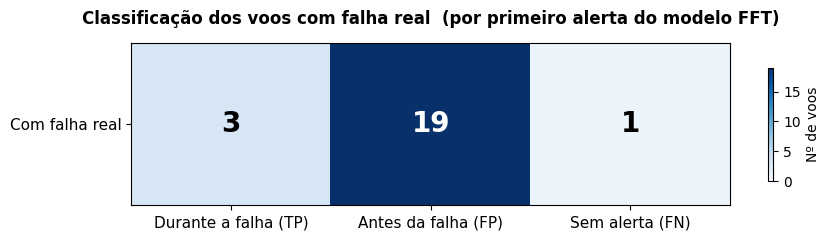

In [8]:
def classify_fault_flight(r: dict) -> str:
    """Classifica um voo com falha real com base no primeiro alerta do modelo."""
    real_idx      = int(np.where(r["y_true"] == 1)[0][0])
    alert_indices = np.where(r["y_pred"] == 1)[0]

    if len(alert_indices) == 0:
        return "Sem alerta (FN)"
    first_alert = int(alert_indices[0])
    if first_alert < real_idx:
        return "Antes da falha (FP)"
    return "Durante a falha (TP)"


CATEGORIES = ["Durante a falha (TP)", "Antes da falha (FP)", "Sem alerta (FN)"]

fault_results = [r for r in all_results if r["has_fault"]]
counts = {cat: 0 for cat in CATEGORIES}

print(f"{'Voo':<60}  Classificação")
print("-" * 80)
for r in fault_results:
    cat = classify_fault_flight(r)
    counts[cat] += 1
    print(f"  {r['flight'].replace('carbonZ_', ''):<58}  {cat}")

print(f"\nTotal de voos com falha real: {len(fault_results)}")
for cat in CATEGORIES:
    print(f"  {cat}: {counts[cat]}")

data = np.array([[counts[cat] for cat in CATEGORIES]])

fig, ax = plt.subplots(figsize=(9, 2.5))
vmax = max(data[0]) if max(data[0]) > 0 else 1
im = ax.imshow(data, cmap="Blues", aspect="auto", vmin=0, vmax=vmax)

ax.set_xticks(range(len(CATEGORIES)))
ax.set_xticklabels(CATEGORIES, fontsize=11)
ax.set_yticks([0])
ax.set_yticklabels(["Com falha real"], fontsize=11)

for j in range(len(CATEGORIES)):
    val = int(data[0, j])
    cor = "white" if val >= vmax * 0.6 else "black"
    ax.text(j, 0, str(val), ha="center", va="center", fontsize=20,
            fontweight="bold", color=cor)

ax.set_title("Classificação dos voos com falha real  (por primeiro alerta do modelo FFT)",
             fontsize=12, fontweight="bold", pad=14)
plt.colorbar(im, ax=ax, shrink=0.7, label="Nº de voos")
plt.tight_layout()
plt.show()

## Matriz de Confusão — Voos sem falha real

Considera apenas os voos **sem falha real** e classifica cada um em uma de duas categorias:

| Categoria | Descrição |
|-----------|----------|
| **Falso alarme (FP)** | Modelo emitiu ao menos um alerta durante o voo |
| **Sem alerta (TN)** | Modelo não emitiu nenhum alerta |

Voo                                                           Classificação
--------------------------------------------------------------------------------
  2018-07-18-16-37-39_1_no_failure                            Sem alerta (TN)
  2018-07-30-16-39-00_3_no_failure                            Falso alarme (FP)
  2018-09-11-14-16-55_no_failure                              Sem alerta (TN)
  2018-09-11-14-41-38_no_failure                              Falso alarme (FP)
  2018-09-11-15-05-11_2_no_failure                            Sem alerta (TN)
  2018-10-05-14-34-20_1_no_failure                            Sem alerta (TN)
  2018-10-05-14-37-22_1_no_failure                            Sem alerta (TN)
  2018-10-05-15-52-12_1_no_failure                            Falso alarme (FP)
  2018-10-05-15-52-12_2_no_failure                            Sem alerta (TN)
  2018-10-18-11-08-24_no_failure                              Sem alerta (TN)

Total de voos sem falha real: 10
  Falso alarme (FP): 3


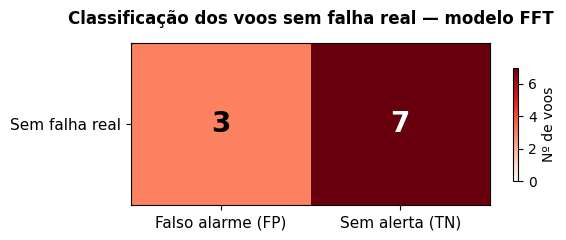

In [9]:
NO_FAULT_CATEGORIES = ["Falso alarme (FP)", "Sem alerta (TN)"]

no_fault_results = [r for r in all_results if not r["has_fault"]]
nf_counts = {cat: 0 for cat in NO_FAULT_CATEGORIES}

print(f"{'Voo':<60}  Classificação")
print("-" * 80)
for r in no_fault_results:
    cat = "Falso alarme (FP)" if r["y_pred"].any() else "Sem alerta (TN)"
    nf_counts[cat] += 1
    print(f"  {r['flight'].replace('carbonZ_', ''):<58}  {cat}")

print(f"\nTotal de voos sem falha real: {len(no_fault_results)}")
for cat in NO_FAULT_CATEGORIES:
    print(f"  {cat}: {nf_counts[cat]}")

nf_data = np.array([[nf_counts[cat] for cat in NO_FAULT_CATEGORIES]])

fig, ax = plt.subplots(figsize=(6, 2.5))
vmax_nf = max(nf_data[0]) if max(nf_data[0]) > 0 else 1
im = ax.imshow(nf_data, cmap="Reds", aspect="auto", vmin=0, vmax=vmax_nf)

ax.set_xticks(range(len(NO_FAULT_CATEGORIES)))
ax.set_xticklabels(NO_FAULT_CATEGORIES, fontsize=11)
ax.set_yticks([0])
ax.set_yticklabels(["Sem falha real"], fontsize=11)

for j in range(len(NO_FAULT_CATEGORIES)):
    val = int(nf_data[0, j])
    cor = "white" if val >= vmax_nf * 0.6 else "black"
    ax.text(j, 0, str(val), ha="center", va="center", fontsize=20,
            fontweight="bold", color=cor)

ax.set_title("Classificação dos voos sem falha real — modelo FFT",
             fontsize=12, fontweight="bold", pad=14)
plt.colorbar(im, ax=ax, shrink=0.7, label="Nº de voos")
plt.tight_layout()
plt.show()